In [1]:
pip install pandas numpy matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("C:/Users/lady/OneDrive/Desktop/DAX INTERNSHIP/bank_fraud.csv")

df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [8]:
df.shape

(1000000, 26)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [10]:
df.describe

<bound method NDFrame.describe of        transaction_id   customer_id transaction_date transaction_time  \
0       TXN0000000001  CUST00121959       2023-08-17         21:13:00   
1       TXN0000000002  CUST00146868       2024-02-06         05:16:00   
2       TXN0000000003  CUST00131933       2024-06-28         12:15:00   
3       TXN0000000004  CUST00103695       2023-03-16         02:53:00   
4       TXN0000000005  CUST00119880       2024-07-12         12:39:00   
...               ...           ...              ...              ...   
999995  TXN0000999996  CUST00176672       2022-11-18         21:15:00   
999996  TXN0000999997  CUST00005742       2021-07-03         22:57:00   
999997  TXN0000999998  CUST00108137       2021-08-12         07:37:00   
999998  TXN0000999999  CUST00117141       2021-06-07         07:09:00   
999999  TXN0001000000  CUST00117401       2021-01-07         18:43:00   

        hour_of_day  is_weekend  is_night_transaction country        city  \
0           

In [11]:
df.isnull().sum()

transaction_id                   0
customer_id                      0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
merchant_category                0
payment_method                   0
device_type                      0
customer_age                     0
credit_score                     0
account_age_years                0
account_balance                  0
transaction_amount               0
num_prev_transactions            0
transaction_freq_monthly         0
distance_from_home_km            0
time_since_last_txn_hrs          0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
fraud_type                  944745
dtype: int64

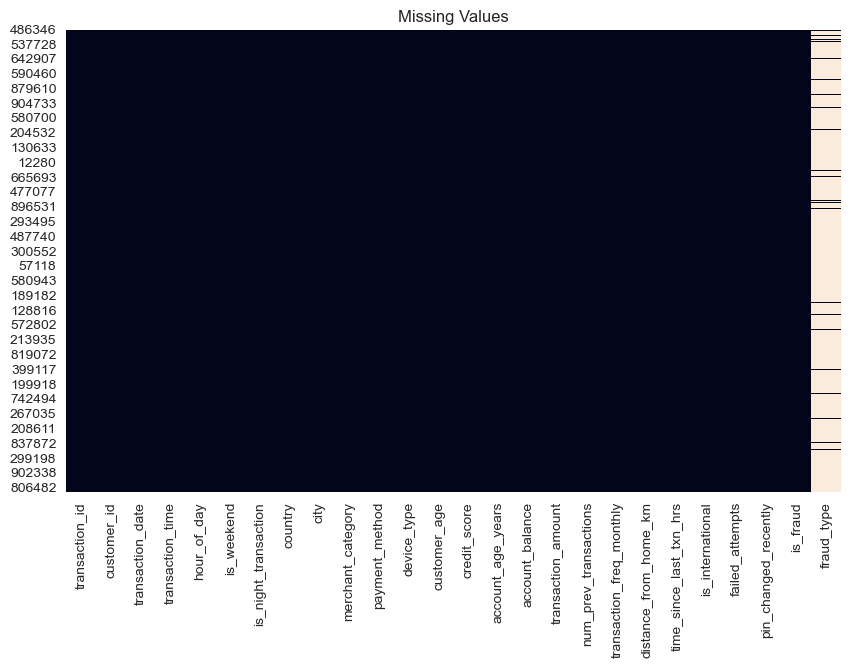

In [14]:
sample = df.sample(500)

plt.figure(figsize=(10,6))
sns.heatmap(sample.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

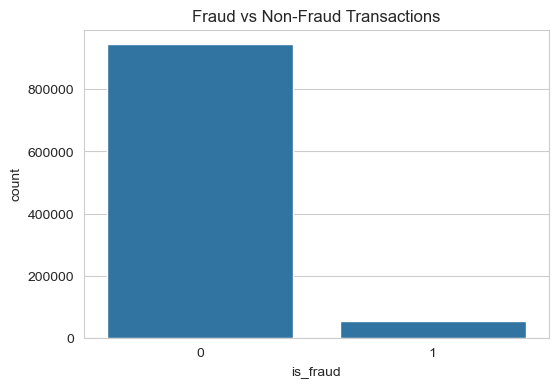

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_fraud',
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

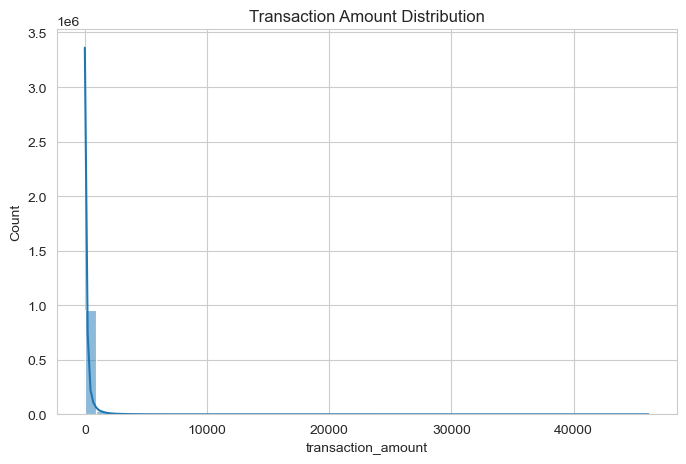

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['transaction_amount'],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.show()

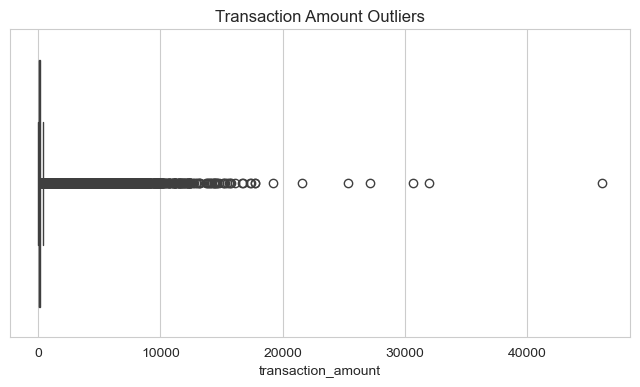

In [23]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['transaction_amount']
)

plt.title("Transaction Amount Outliers")
plt.show()

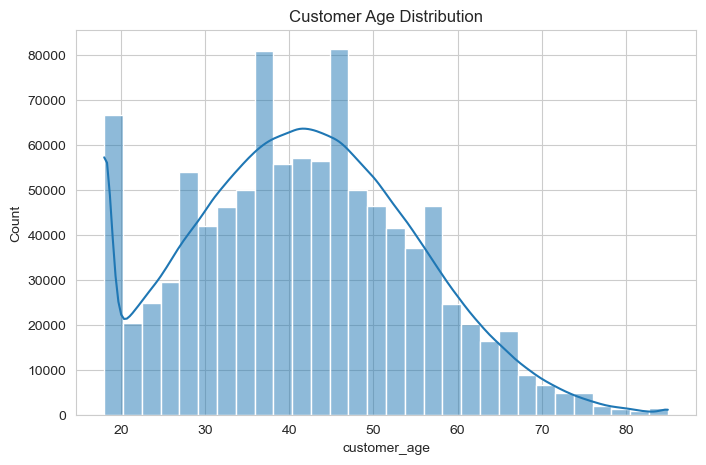

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['customer_age'],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.show()

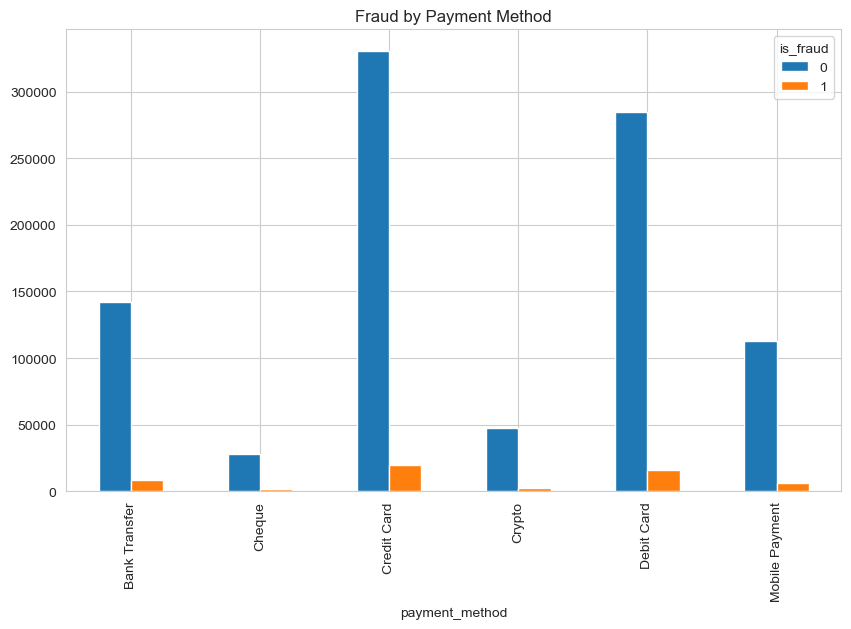

In [25]:
fraud_payment = pd.crosstab(
    df['payment_method'],
    df['is_fraud']
)

fraud_payment.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Fraud by Payment Method")
plt.show()

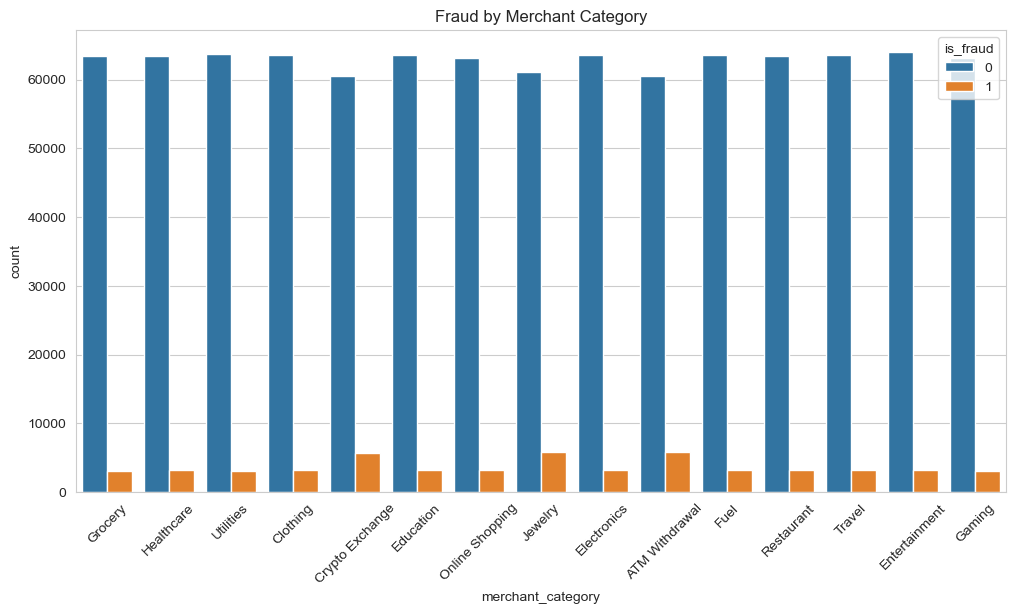

In [26]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='merchant_category',
    hue='is_fraud',
    data=df
)

plt.xticks(rotation=45)
plt.title("Fraud by Merchant Category")
plt.show()

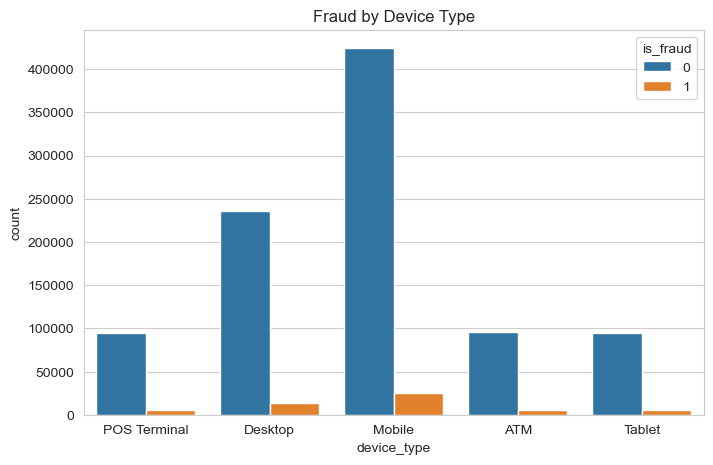

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='device_type',
    hue='is_fraud',
    data=df
)

plt.title("Fraud by Device Type")
plt.show()

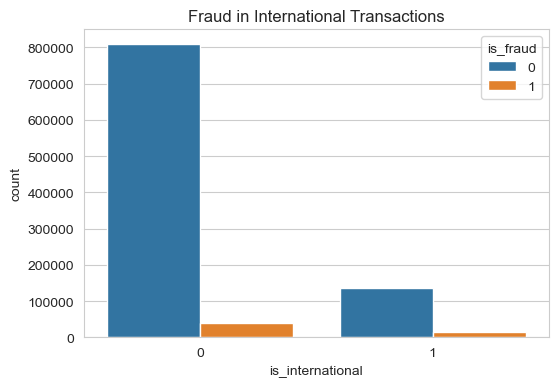

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_international',
    hue='is_fraud',
    data=df
)

plt.title("Fraud in International Transactions")
plt.show()

In [29]:
num_cols = df.select_dtypes(
    include=['int64','float64']
)

corr = num_cols.corr()

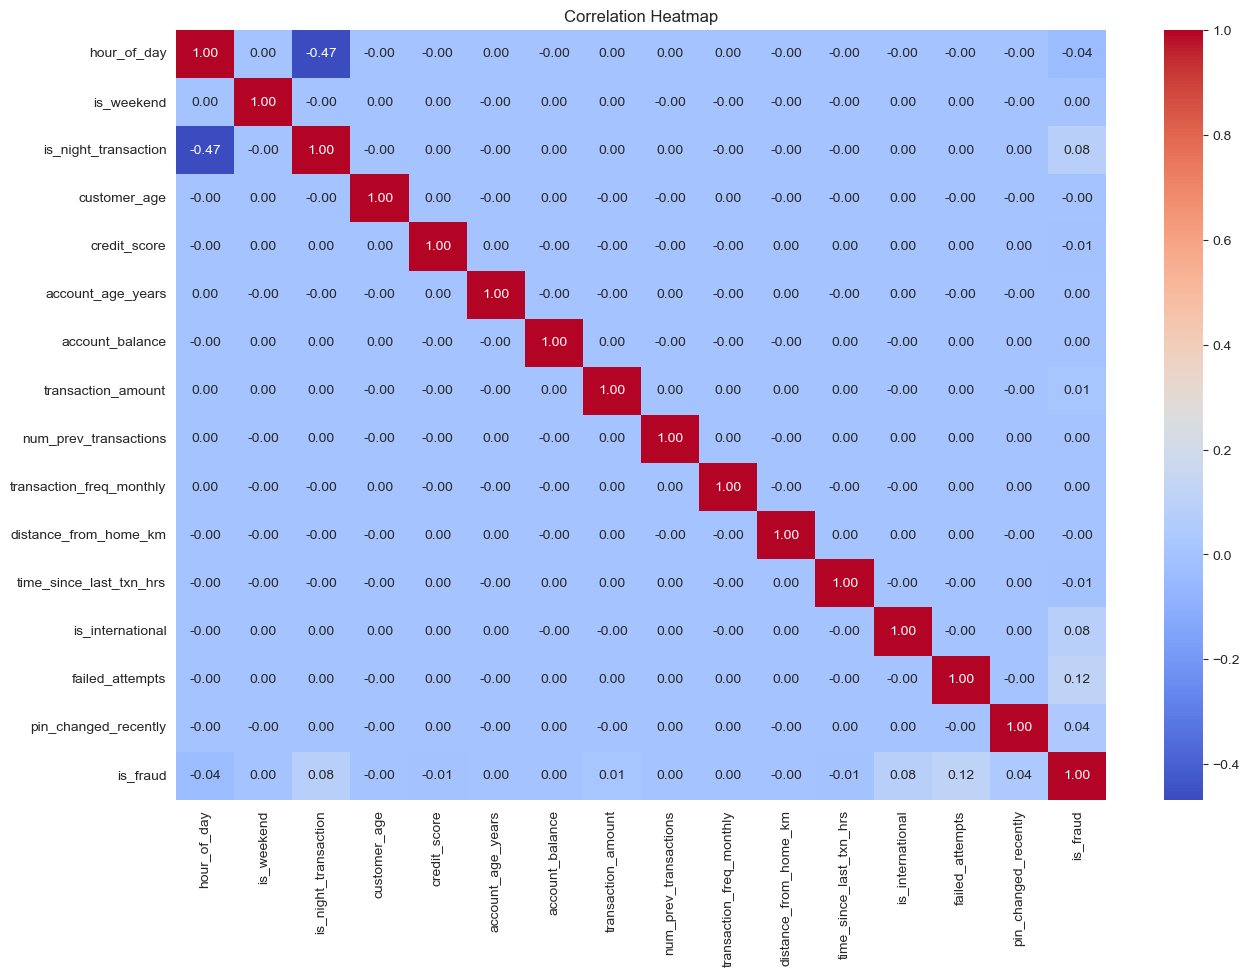

In [30]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

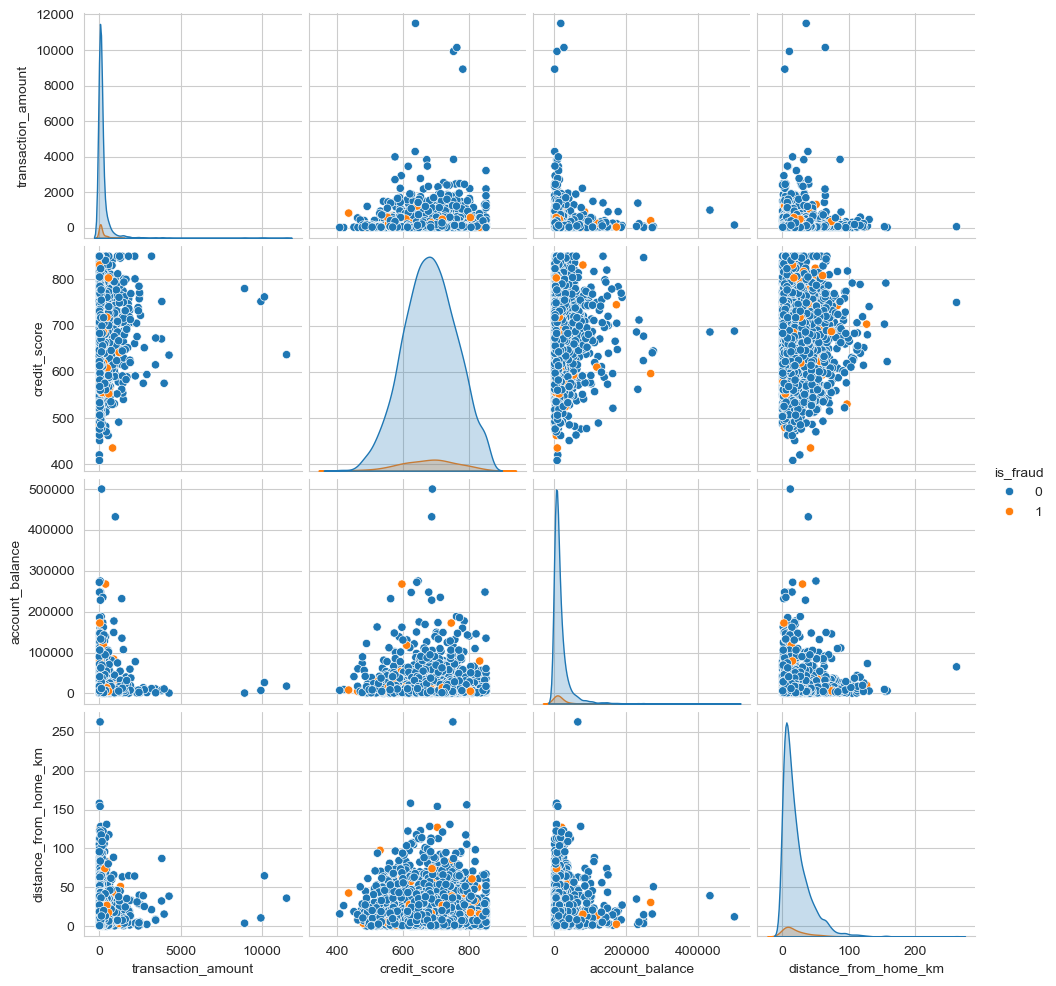

In [31]:
sample = df.sample(3000)

sns.pairplot(
    sample[
        [
            'transaction_amount',
            'credit_score',
            'account_balance',
            'distance_from_home_km',
            'is_fraud'
        ]
    ],
    hue='is_fraud'
)

plt.show()

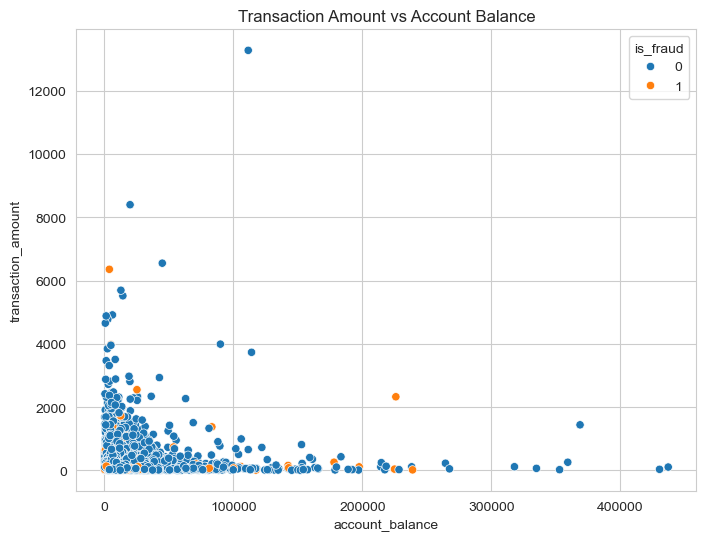

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='account_balance',
    y='transaction_amount',
    hue='is_fraud',
    data=df.sample(5000)
)

plt.title("Transaction Amount vs Account Balance")
plt.show()

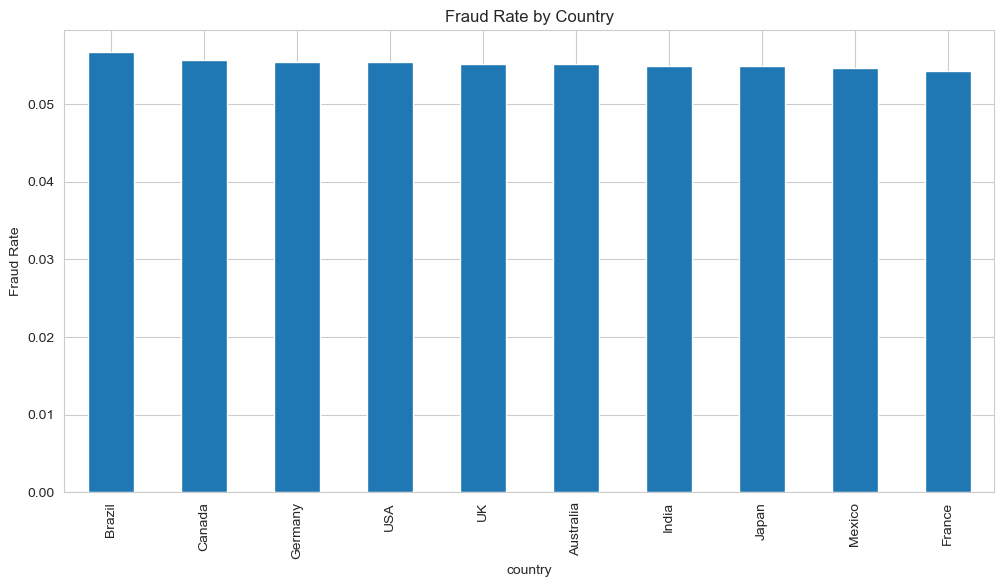

In [33]:
country_fraud = df.groupby(
    'country'
)['is_fraud'].mean().sort_values(ascending=False)

country_fraud.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Fraud Rate by Country")
plt.ylabel("Fraud Rate")
plt.show()